# 6 Test Environment Impassible Terrain

Building on from the previous notepads I intend to add impassible terrain to this model, This can be used to represent listed buildings or areas that cannot be demolished such a protected forests for a train-line. 

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap

import sys
sys.path.append("../src")
from terrain.terrain import Terrain
from geometry.endpoints import Endpoints
from geometry.path import Path
from geometry.generators import straight_line_path, find_feasible_initial_path


### terrain ### 
terrain = Terrain(
    width=100,
    height=100,
    resolution=100,
    cost=0.1
)


terrain.add_hill(
    centre=(50, 50),
    peak_cost=50,
    radius=30
)

terrain.add_impassable_square(
    bottom_left=(30,40),
    top_right=(40,50),
)


### boundarys ###

boundary = Endpoints(
    start=(10, 20),
    end=(80, 80)
)

boundary_df = boundary.to_dataframe()


terrain.grid.shape
terrain_df = terrain.to_dataframe()

### Initial Path
initial_path = straight_line_path(
    start=boundary.start,
    end=boundary.end,
    num_points=100
)

# initial_path = find_feasible_initial_path(
#     initial_path,
#     terrain,
#     sigma=3,
#     alpha=10,
#     max_attempts=10000
# )

initial_path_df = initial_path.to_dataframe()

In [2]:
print(terrain.impassable)

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


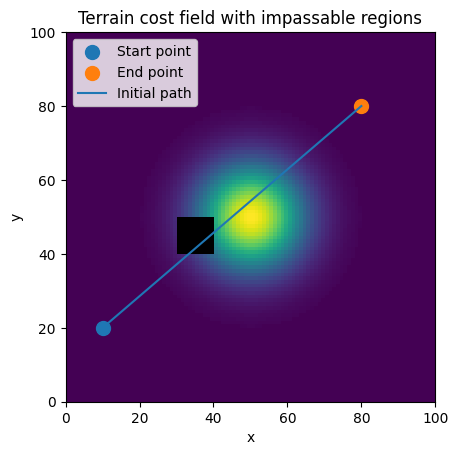

In [3]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

# Plot only impassable cells
plt.imshow(
    np.ma.masked_where(
        ~terrain.impassable,
        terrain.impassable
    ),
    extent=[0, terrain.width, 0, terrain.height],
    origin="lower",
    cmap=ListedColormap(["black"])

)

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.plot(
    initial_path_df["x"],
    initial_path_df["y"],
    label="Initial path"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with impassable regions")

plt.legend()
plt.show()

In [4]:
from cost_functions.terrain_cost import terrain_cost, terrain_curvature_cost, terrain_length_cost




print(terrain_cost(initial_path, terrain))
print(terrain_curvature_cost(initial_path))
print(terrain_length_cost(initial_path))


1193.8650652339363
1.555318160733747e-26
92.19544457292892


The purpose of this notepad is to work out normalised weightings for this function and to experiment with the results. Our weight vector contains $(w_c,\lambda,\mu)$.

My plan is turn my objective fucntion into the following 
$$
J(\gamma) = \frac{w_c}{C_0(\gamma)}C(\gamma) + \frac{\lambda}{K_0(\gamma)}K(\gamma) + \frac{\mu}{L_0(\gamma)}L(\gamma)
$$
Where 
$$
w_c + \lambda + \mu = 1
$$

Using the initial weights will not work as the curvature initial cost $K_0$ is so small diving by it will explode the value of lambda. I'm going to apply a fixed amount of random perturbations to get a better value for the weights. 

In [5]:
from optimisation.moves import segment_shift_move

terrain_scale = np.mean([
    terrain_cost(segment_shift_move(path=initial_path, terrain=terrain, sigma=0.3, alpha =10), terrain)
    for _ in range(50)
])

curvature_scale = np.mean([
    terrain_curvature_cost(segment_shift_move(path=initial_path, terrain=terrain, sigma=0.3, alpha =10))
    for _ in range(50)
])

length_scale = np.mean([
    terrain_length_cost(segment_shift_move(path=initial_path, terrain=terrain, sigma=0.3, alpha =10))
    for _ in range(50)
])

terrain_scale_std = np.std([
    terrain_cost(segment_shift_move(path=initial_path, terrain=terrain, sigma=0.3, alpha =10), terrain)
    for _ in range(50)
])

curvature_scale_std = np.std([
    terrain_curvature_cost(segment_shift_move(path=initial_path, terrain=terrain, sigma=0.3, alpha =10))
    for _ in range(50)
])

length_scale_std = np.std([
    terrain_length_cost(segment_shift_move(path=initial_path, terrain=terrain, sigma=0.3, alpha =10))
    for _ in range(50)
])

print(terrain_cost(initial_path, terrain))
print(terrain_curvature_cost(initial_path))
print(terrain_length_cost(initial_path))

print(terrain_scale)
print(curvature_scale)
print(length_scale)

print(terrain_scale_std)
print(curvature_scale_std)
print(length_scale_std)

1193.8650652339363
1.555318160733747e-26
92.19544457292892
1196.647218026787
0.6704713968298759
92.27601463205387
5.164028441795642
0.37966128042211666
0.10768641160334043


In [6]:
sample_paths = [
    segment_shift_move(
        path=initial_path,
        terrain=terrain,
        sigma=10,
        alpha=10
    )
    for _ in range(1000)
]

terrain_values = [
    terrain_cost(p, terrain)
    for p in sample_paths
]

curvature_values = [
    terrain_curvature_cost(p)
    for p in sample_paths
]

length_values = [
    terrain_length_cost(p)
    for p in sample_paths
]


terrain_scale = np.mean(terrain_values)
curvature_scale = np.mean(curvature_values)
length_scale = np.mean(length_values)

print(terrain_scale)
print(curvature_scale)
print(length_scale)

KeyboardInterrupt: 

In [ ]:
from cost_functions.terrain_cost import terrain_cost, total_cost

w_c = 0.8/terrain_scale
lam = 0.05/curvature_scale
mu = 0.15/length_scale

print(total_cost(
                        initial_path,
                        terrain,
                        w_c,
                        lam,
                        mu
                    ))

0.8837893580564268


In [ ]:
terrain_component = w_c * terrain_cost(initial_path, terrain)
curvature_component = lam * terrain_curvature_cost(initial_path)
length_component = mu * terrain_length_cost(initial_path)

print(terrain_component)
print(curvature_component)
print(length_component)
print(sum([
    terrain_component,
    curvature_component,
    length_component
]))

0.6854934417286261
7.145942511429173e-29
0.19829591632780064
0.8837893580564268


In [ ]:
from optimisation.annealing import simulated_segment_annealing_curvature


best_path_segment, best_cost_segment, history_segment, path_history_segment = simulated_segment_annealing_curvature(
    initial_path=initial_path,
    terrain=terrain,
    iterations=10000,
    initial_temperature=1,
    cooling_rate=0.999,
    sigma=3,
    alpha=10,
    terrain_weight=w_c,
    lam=lam,
    mu=mu
)


=== Annealing Parameters ===
Terrain weight (w_c): 0.0005741799988043914
Curvature weight (lambda): 0.004594521360219929
Length weight (mu): 0.0021508211956279854
Initial cost: 0.8837893580564268

Iteration: 0
Current cost: 0.8837893580564268
Candidate cost: 0.8837893580564268
Delta: 0.0
Candidate components:
Terrain: 1193.8650652339363
Curvature: 1.555318160733747e-26
Length: 92.19544457292892

Iteration: 1
Current cost: 0.8837893580564268
Candidate cost: 0.8837893580564268
Delta: 0.0
Candidate components:
Terrain: 1193.8650652339363
Curvature: 1.555318160733747e-26
Length: 92.19544457292892

Iteration: 2
Current cost: 0.8837893580564268
Candidate cost: 0.8837893580564268
Delta: 0.0
Candidate components:
Terrain: 1193.8650652339363
Curvature: 1.555318160733747e-26
Length: 92.19544457292892

Iteration: 3
Current cost: 0.8837893580564268
Candidate cost: 0.8837893580564268
Delta: 0.0
Candidate components:
Terrain: 1193.8650652339363
Curvature: 1.555318160733747e-26
Length: 92.19544457292

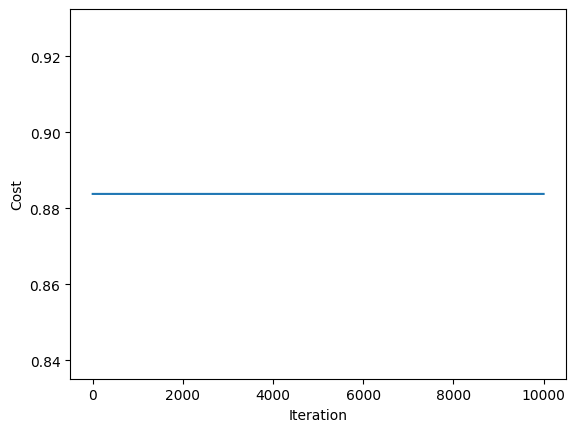

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

history_segment_df = pd.DataFrame(history_segment)

plt.plot(
    history_segment_df["best_cost"]
)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [ ]:

best_path_segment_df = best_path_segment.to_dataframe()


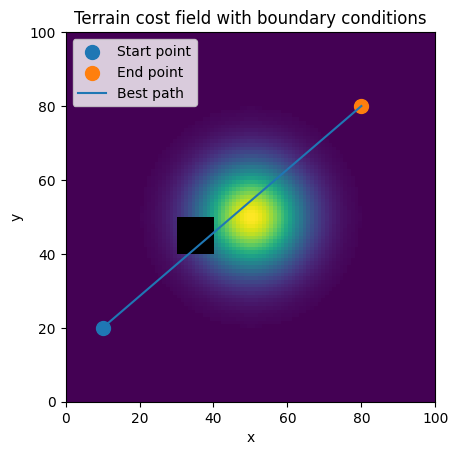

In [ ]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)
# Plot only impassable cells
plt.imshow(
    np.ma.masked_where(
        ~terrain.impassable,
        terrain.impassable
    ),
    extent=[0, terrain.width, 0, terrain.height],
    origin="lower",
    cmap=ListedColormap(["black"])

)

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.plot( 
    best_path_segment_df["x"],
    best_path_segment_df["y"],
    label="Best path"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with boundary conditions")

plt.legend()
plt.show()

In [ ]:
print(terrain_cost(initial_path, terrain))
print(terrain_curvature_cost(initial_path))
print(terrain_length_cost(initial_path))
print(total_cost(initial_path,terrain, w_c, lam, mu))



print(terrain_cost(best_path_segment, terrain))
print(terrain_curvature_cost(best_path_segment))
print(terrain_length_cost(best_path_segment))
print(total_cost(best_path_segment,terrain, w_c, lam, mu))

1193.8650652339363
1.555318160733747e-26
92.19544457292892
0.8837893580564268
1193.8650652339363
1.555318160733747e-26
92.19544457292892
0.8837893580564268


In [ ]:
print(best_path_segment_df.to_string(index=False))

 point         x         y
     0 10.000000 20.000000
     1 10.707071 20.606061
     2 11.414141 21.212121
     3 12.121212 21.818182
     4 12.828283 22.424242
     5 13.535354 23.030303
     6 14.242424 23.636364
     7 14.949495 24.242424
     8 15.656566 24.848485
     9 16.363636 25.454545
    10 17.070707 26.060606
    11 17.777778 26.666667
    12 18.484848 27.272727
    13 19.191919 27.878788
    14 19.898990 28.484848
    15 20.606061 29.090909
    16 21.313131 29.696970
    17 22.020202 30.303030
    18 22.727273 30.909091
    19 23.434343 31.515152
    20 24.141414 32.121212
    21 24.848485 32.727273
    22 25.555556 33.333333
    23 26.262626 33.939394
    24 26.969697 34.545455
    25 27.676768 35.151515
    26 28.383838 35.757576
    27 29.090909 36.363636
    28 29.797980 36.969697
    29 30.505051 37.575758
    30 31.212121 38.181818
    31 31.919192 38.787879
    32 32.626263 39.393939
    33 33.333333 40.000000
    34 34.040404 40.606061
    35 34.747475 41.212121
 

In [ ]:
print(len(path_history_segment))

0


Animation for posting and showing Yasemin

/Users/danielskerman/Documents/Masters/Dissertation/msc-calculus-of-variations/numerical/.venv/lib/python3.9/site-packages/matplotlib/animation.py:1725: UserWarning: Can not start iterating the frames for the initial draw. This can be caused by passing in a 0 length sequence for *frames*.

If you passed *frames* as a generator it may be exhausted due to a previous display or save.
  warnings.warn(
/Users/danielskerman/Documents/Masters/Dissertation/msc-calculus-of-variations/numerical/.venv/lib/python3.9/site-packages/matplotlib/animation.py:1725: UserWarning: Can not start iterating the frames for the initial draw. This can be caused by passing in a 0 length sequence for *frames*.

If you passed *frames* as a generator it may be exhausted due to a previous display or save.
  warnings.warn(


IndexError: list index out of range

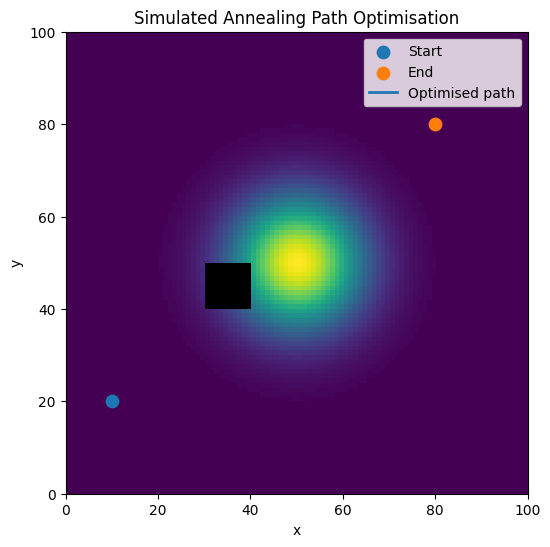

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Reduce frames for LinkedIn
linkedin_history = path_history_segment[::2]


fig, ax = plt.subplots(figsize=(6, 6))

# Plot terrain background
ax.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

# Plot only impassable cells
ax.imshow(
    np.ma.masked_where(
        ~terrain.impassable,
        terrain.impassable
    ),
    extent=[0, terrain.width, 0, terrain.height],
    origin="lower",
    cmap=ListedColormap(["black"])

)


# Plot start/end points
ax.scatter(
    boundary.start[0],
    boundary.start[1],
    s=80,
    label="Start"
)

ax.scatter(
    boundary.end[0],
    boundary.end[1],
    s=80,
    label="End"
)

# Empty path line
line, = ax.plot(
    [],
    [],
    linewidth=2,
    label="Optimised path"
)

# Iteration counter
iteration_text = ax.text(
    0.02,
    0.90,
    "",
    transform=ax.transAxes,
    bbox=dict(
        boxstyle="round",
        alpha=0.8
    )
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Simulated Annealing Path Optimisation")

ax.legend()


def update(frame):

    path = linkedin_history[frame]

    points = path.points

    line.set_data(
        points[:, 0],
        points[:, 1]
    )

    # Calculate current path cost
    current_cost = total_cost(
        path,
        terrain,
        w_c,
        lam,
        mu
    )

    # Recover original iteration number
    iteration_text.set_text(
        f"Iteration: {frame * 2}\n"
        f"Cost: {current_cost:.2f}"
    )

    return line, iteration_text

animation = FuncAnimation(
    fig,
    update,
    frames=len(linkedin_history),
    interval=50,
    blit=True
)


animation.save(
    "/Users/danielskerman/Documents/Masters/Dissertation/msc-calculus-of-variations/numerical/outputs/linkedin_path_impassible_terrain.gif",
    writer="pillow",
    fps=40
)

plt.close()